# 35 Select StyleGAN2 Sparse Snapshots DIBaS

This notebook does not retrain StyleGAN2-ADA.
It reuses the existing checkpoints and KID records from `04_train_gan_make_images_dibas`, then applies the fixed sparse snapshot rule `[40, 80, 120, 160, 200]`.

The original notebook, original results, original generated images, and original manifests are not overwritten.
New outputs are saved under `35_select_stylegan2_sparse_snapshots_dibas` and `stylegan2_sparse` paths.

In [1]:
# We keep this notebook separate so the completed StyleGAN2-ADA run is not overwritten.
from pathlib import Path
import csv
import json
import os
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image


def find_repo_root(start_path: Path) -> Path:
    current_path = start_path.resolve()
    for candidate in [current_path, *current_path.parents]:
        if (candidate / "notebooks").exists() and (candidate / "manifests").exists():
            return candidate
    raise RuntimeError("Could not find the FYP2 repository root.")


REPO_ROOT = find_repo_root(Path.cwd())
MANIFESTS_DIR = REPO_ROOT / "manifests"
RESULTS_DIR = REPO_ROOT / "results"
CHECKPOINTS_DIR = REPO_ROOT / "checkpoints"
THIRD_PARTY_DIR = REPO_ROOT / "third_party"
STYLEGAN_DIR = THIRD_PARTY_DIR / "stylegan2-ada-pytorch"

DATASET_NAME = "dibas"
SOURCE_NOTEBOOK_TAG = "04_train_gan_make_images_dibas"
NOTEBOOK_TAG = "35_select_stylegan2_sparse_snapshots_dibas"
SOURCE_RESULTS_DIR = RESULTS_DIR / SOURCE_NOTEBOOK_TAG
NOTEBOOK_RESULTS_DIR = RESULTS_DIR / NOTEBOOK_TAG
GAN_IMAGES_256_DIR = REPO_ROOT / "gan_images_256" / "stylegan2_sparse/dibas"
GAN_IMAGES_224_DIR = REPO_ROOT / "gan_images_224" / "stylegan2_sparse/dibas"

REAL_PATCH_MANIFEST_PATH = MANIFESTS_DIR / "patch_manifest_224.csv"
GAN_SOURCE_MANIFEST_PATH = MANIFESTS_DIR / "gan_patch_manifest_256.csv"
FOLD_MANIFEST_PATH = MANIFESTS_DIR / "fold_manifest.csv"
ORIGINAL_FOLD_PLAN_PATH = SOURCE_RESULTS_DIR / "fold_plan.csv"
ORIGINAL_KID_SNAPSHOT_PATH = SOURCE_RESULTS_DIR / "kid_snapshot_results.csv"
ORIGINAL_KID_RESULT_PATH = SOURCE_RESULTS_DIR / "kid_results.csv"
ORIGINAL_TRAINING_MANIFEST_PATH = SOURCE_RESULTS_DIR / "training_run_manifest.csv"

MANIFEST_256_PATH = MANIFESTS_DIR / "stylegan2_sparse_generated_manifest_256.csv"
MANIFEST_224_PATH = MANIFESTS_DIR / "stylegan2_sparse_generated_manifest_224.csv"

FOLDS_TO_RUN = [1, 2, 3, 4, 5]
SPARSE_SNAPSHOT_KIMG = [40, 80, 120, 160, 200]
CNN_PATCH_SIZE = 224
GENERATE_START_SEED = 10000
GENERATE_NOISE_MODE = "random"
BINARY_LABEL = 0
BINARY_GROUP = "cocci"
SOURCE_TYPE = "stylegan2_sparse_generated"
ALLOW_OVERWRITE_SPARSE_OUTPUTS = False
LONG_COMMAND_NOTEBOOK_MODE = "smart"
KID_METRIC_NAME = "kid50k_full"
KID_OPENMP_DUPLICATE_OK = True

# Use forward slashes so this path is safe inside the notebook JSON and valid on Windows.
STYLEGAN_WINDOWS_PYTHON = Path("C:/Users/FYP2610/anaconda3/envs/fyp2_stylegan2ada/python.exe")
STYLEGAN_TORCH_CUDA_ARCH_LIST = "8.0+PTX"
STYLEGAN_EXTENSIONS_DIR = CHECKPOINTS_DIR / "torch_extensions_sm80ptx"
STYLEGAN_EXTENSIONS_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not STYLEGAN_DIR.exists():
    raise FileNotFoundError(f"Missing StyleGAN2-ADA folder: {STYLEGAN_DIR}")
if not SOURCE_RESULTS_DIR.exists():
    raise FileNotFoundError(f"Missing source results folder: {SOURCE_RESULTS_DIR}")

if os.name == "nt":
    PYTHON_EXE = STYLEGAN_WINDOWS_PYTHON
    if not PYTHON_EXE.exists():
        raise FileNotFoundError(f"Could not find StyleGAN Python: {PYTHON_EXE}")
    STYLEGAN_ENV_ROOT = PYTHON_EXE.parent
    CONDA_EXE = STYLEGAN_ENV_ROOT.parent.parent / "Scripts" / "conda.exe"
    if not CONDA_EXE.exists():
        raise FileNotFoundError(f"Could not find conda.exe: {CONDA_EXE}")
else:
    PYTHON_EXE = Path(sys.executable)
    STYLEGAN_ENV_ROOT = None
    CONDA_EXE = None

STYLEGAN_EXTRA_ENV = {
    "TORCH_CUDA_ARCH_LIST": STYLEGAN_TORCH_CUDA_ARCH_LIST,
    "TORCH_EXTENSIONS_DIR": str(STYLEGAN_EXTENSIONS_DIR),
}
if KID_OPENMP_DUPLICATE_OK:
    STYLEGAN_EXTRA_ENV["KMP_DUPLICATE_LIB_OK"] = "TRUE"

def build_stylegan_command(script_name: str, *script_args: str):
    if os.name == "nt":
        return [
            str(CONDA_EXE),
            "run",
            "--no-capture-output",
            "-p",
            str(STYLEGAN_ENV_ROOT),
            "python",
            script_name,
            *script_args,
        ]
    return [str(PYTHON_EXE), script_name, *script_args]

In [2]:
# These helpers keep the notebook direct and easy to audit.
def read_csv_rows(csv_path: Path):
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing CSV file: {csv_path}")
    with csv_path.open("r", newline="", encoding="utf-8") as csv_file:
        return list(csv.DictReader(csv_file))

def write_csv_rows(csv_path: Path, rows, fieldnames):
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with csv_path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def write_json(json_path: Path, data):
    json_path.parent.mkdir(parents=True, exist_ok=True)
    with json_path.open("w", encoding="utf-8") as json_file:
        json.dump(data, json_file, indent=2)

def as_repo_relative(repo_root: Path, path_value: Path) -> str:
    return str(path_value.resolve().relative_to(repo_root.resolve())).replace(chr(92), "/")

def safe_prepare_output_dir(output_dir: Path):
    if output_dir.exists() and any(output_dir.iterdir()):
        if not ALLOW_OVERWRITE_SPARSE_OUTPUTS:
            raise FileExistsError(
                f"Refusing to overwrite existing sparse output folder: {output_dir}. "
                "Set ALLOW_OVERWRITE_SPARSE_OUTPUTS=True only if you intentionally want to rerun this new sparse notebook."
            )
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

def should_echo_command_line(line_text: str, line_number: int, notebook_mode: str):
    if notebook_mode == "all":
        return True
    if notebook_mode == "none":
        return False
    important_markers = ["Generating image for seed", "Error", "Traceback", "Done"]
    lowered = line_text.lower()
    return line_number <= 20 or any(marker.lower() in lowered for marker in important_markers)

def run_command(command_parts, workdir: Path, live_log_path: Path, notebook_mode: str = "smart", extra_env=None):
    live_log_path.parent.mkdir(parents=True, exist_ok=True)
    command_env = os.environ.copy()
    if extra_env is not None:
        command_env.update(extra_env)

    process = subprocess.Popen(
        command_parts,
        cwd=workdir,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        env=command_env,
    )

    start_time = time.time()
    output_tail = []
    total_line_count = 0
    printed_line_count = 0
    suppressed_line_count = 0

    with live_log_path.open("w", encoding="utf-8") as log_handle:
        for line in process.stdout:
            total_line_count += 1
            output_tail.append(line)
            output_tail = output_tail[-200:]
            log_handle.write(line)
            log_handle.flush()

            line_text = line.rstrip()
            if should_echo_command_line(line_text, total_line_count, notebook_mode):
                print(line_text)
                printed_line_count += 1
            else:
                suppressed_line_count += 1

    returncode = process.wait()
    duration_seconds = round(time.time() - start_time, 2)
    return {
        "command": " ".join(str(item) for item in command_parts),
        "returncode": returncode,
        "duration_seconds": duration_seconds,
        "printed_line_count": printed_line_count,
        "suppressed_line_count": suppressed_line_count,
        "total_line_count": total_line_count,
        "log_path": as_repo_relative(REPO_ROOT, live_log_path),
        "output_tail": "".join(output_tail),
    }

,fold_id,snapshot_path,snapshot_kimg,kid50k_full
0,1,checkpoints/04_train_gan_make_images_dibas/fol...,160,0.060583
1,2,checkpoints/04_train_gan_make_images_dibas/fol...,200,0.072077
2,3,checkpoints/04_train_gan_make_images_dibas/fol...,200,0.029700
3,4,checkpoints/04_train_gan_make_images_dibas/fol...,200,0.061662
4,5,checkpoints/04_train_gan_make_images_dibas/fol...,200,0.035033


,fold_id,original_selected_kimg,original_selected_kid50k_full,sparse_selected_kimg,sparse_selected_kid50k_full,kid_delta_sparse_minus_original
0,1,184,0.044760,160,0.060583,0.015824
1,2,192,0.071032,200,0.072077,0.001045
2,3,184,0.027735,200,0.029700,0.001964
3,4,168,0.052823,200,0.061662,0.008838
4,5,200,0.035033,200,0.035033,0.000000


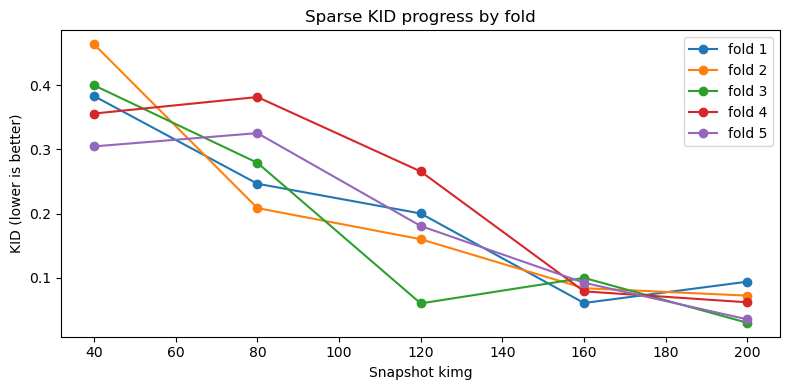

In [3]:
# We load the completed StyleGAN2-ADA records and reselect from the fixed sparse candidates only.
fold_plan_rows = read_csv_rows(ORIGINAL_FOLD_PLAN_PATH)
all_kid_snapshot_rows = read_csv_rows(ORIGINAL_KID_SNAPSHOT_PATH)
original_best_rows = read_csv_rows(ORIGINAL_KID_RESULT_PATH)
training_run_rows = read_csv_rows(ORIGINAL_TRAINING_MANIFEST_PATH)

for row in fold_plan_rows:
    row["train_fold_id"] = int(row["train_fold_id"])
    row["needed_gan_count_224"] = int(row["needed_gan_count_224"])

for row in all_kid_snapshot_rows:
    row["fold_id"] = int(row["fold_id"])
    row["snapshot_kimg"] = int(row["snapshot_kimg"])
    row["kid50k_full"] = float(row["kid50k_full"])

for row in original_best_rows:
    row["fold_id"] = int(row["fold_id"])
    row["snapshot_kimg"] = int(row["snapshot_kimg"])
    row["kid50k_full"] = float(row["kid50k_full"])

candidate_kimg_set = set(SPARSE_SNAPSHOT_KIMG)
sparse_candidate_rows = [row for row in all_kid_snapshot_rows if row["snapshot_kimg"] in candidate_kimg_set]
if not sparse_candidate_rows:
    raise RuntimeError("No sparse KID candidates were found. Check the original StyleGAN2-ADA KID results.")

kid_rows = []
comparison_rows = []
original_best_lookup = {int(row["fold_id"]): row for row in original_best_rows}

for fold_id in FOLDS_TO_RUN:
    fold_candidates = [row for row in sparse_candidate_rows if int(row["fold_id"]) == fold_id]
    available_kimg = sorted(int(row["snapshot_kimg"]) for row in fold_candidates)
    if available_kimg != SPARSE_SNAPSHOT_KIMG:
        raise RuntimeError(f"Fold {fold_id} sparse candidates are {available_kimg}, expected {SPARSE_SNAPSHOT_KIMG}.")

    best_sparse_row = sorted(fold_candidates, key=lambda row: (float(row["kid50k_full"]), int(row["snapshot_kimg"])))[0]
    snapshot_path = REPO_ROOT / best_sparse_row["snapshot_path"]
    if not snapshot_path.exists():
        raise FileNotFoundError(
            f"Missing checkpoint for fold {fold_id} sparse selection: {snapshot_path}. "
            "Copy the original checkpoints folder back before running this notebook."
        )

    kid_rows.append(best_sparse_row)
    original_best = original_best_lookup[fold_id]
    comparison_rows.append({
        "fold_id": fold_id,
        "original_selected_kimg": int(original_best["snapshot_kimg"]),
        "original_selected_kid50k_full": float(original_best["kid50k_full"]),
        "sparse_selected_kimg": int(best_sparse_row["snapshot_kimg"]),
        "sparse_selected_kid50k_full": float(best_sparse_row["kid50k_full"]),
        "kid_delta_sparse_minus_original": float(best_sparse_row["kid50k_full"]) - float(original_best["kid50k_full"]),
    })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "kid_snapshot_results_sparse.csv", sparse_candidate_rows, list(sparse_candidate_rows[0].keys()))
write_csv_rows(NOTEBOOK_RESULTS_DIR / "kid_results.csv", kid_rows, list(kid_rows[0].keys()))
write_csv_rows(NOTEBOOK_RESULTS_DIR / "snapshot_selection_comparison.csv", comparison_rows, list(comparison_rows[0].keys()))

kid_df = pd.DataFrame(kid_rows)
comparison_df = pd.DataFrame(comparison_rows)
display(kid_df)
display(comparison_df)

fig, axis = plt.subplots(figsize=(8, 4))
sparse_df = pd.DataFrame(sparse_candidate_rows)
for fold_id in sorted(sparse_df["fold_id"].unique()):
    current = sparse_df[sparse_df["fold_id"] == fold_id].sort_values("snapshot_kimg")
    axis.plot(current["snapshot_kimg"], current["kid50k_full"], marker="o", label=f"fold {fold_id}")
axis.set_xlabel("Snapshot kimg")
axis.set_ylabel("KID (lower is better)")
axis.set_title("Sparse KID progress by fold")
axis.legend()
fig.tight_layout()
fig.savefig(NOTEBOOK_RESULTS_DIR / "kid_progress_sparse_by_fold.png", dpi=200)
plt.show()

In [4]:
# We generate images from the selected sparse checkpoints only. This only calls the generator script.
generated_rows_256 = []
generation_report_rows = []
kid_lookup = {int(row["fold_id"]): row for row in kid_rows}

for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    snapshot_path = REPO_ROOT / kid_lookup[fold_id]["snapshot_path"]
    generated_256_dir = GAN_IMAGES_256_DIR / f"fold_{fold_id}"
    safe_prepare_output_dir(generated_256_dir)

    needed_count = int(fold_plan["needed_gan_count_224"])
    start_seed = GENERATE_START_SEED + (fold_id * 10000)
    end_seed = start_seed + needed_count - 1
    seed_text = f"{start_seed}-{end_seed}"
    fold_result_dir = NOTEBOOK_RESULTS_DIR / f"fold_{fold_id}"

    report = run_command(
        build_stylegan_command(
            "generate.py",
            f"--network={snapshot_path}",
            f"--seeds={seed_text}",
            f"--outdir={generated_256_dir}",
            f"--noise-mode={GENERATE_NOISE_MODE}",
        ),
        STYLEGAN_DIR,
        fold_result_dir / "generate_sparse.log",
        notebook_mode=LONG_COMMAND_NOTEBOOK_MODE,
        extra_env=STYLEGAN_EXTRA_ENV,
    )
    write_json(fold_result_dir / "generate_sparse_report.json", report)
    if report["returncode"] != 0:
        raise RuntimeError(f"Sparse StyleGAN2 generation failed for fold {fold_id}")

    generated_files = sorted(generated_256_dir.glob("seed*.png"))
    if len(generated_files) != needed_count:
        raise RuntimeError(f"Fold {fold_id} should have {needed_count} generated images, but found {len(generated_files)}.")

    generation_report_rows.append({
        "fold_id": fold_id,
        "selected_snapshot_kimg": int(kid_lookup[fold_id]["snapshot_kimg"]),
        "selected_kid50k_full": float(kid_lookup[fold_id]["kid50k_full"]),
        "needed_gan_count_224": needed_count,
        "generated_count_256": len(generated_files),
        "generate_duration_seconds": report["duration_seconds"],
    })

    test_fold_ids = fold_plan["test_fold_ids"]
    for generated_file in generated_files:
        seed = int(generated_file.stem.replace("seed", ""))
        generated_rows_256.append({
            "dataset_name": DATASET_NAME,
            "gan_image_id": f"stylegan2_sparse_dibas_fold{fold_id}_seed{seed}_256",
            "fold_id": fold_id,
            "round_id": fold_id,
            "train_fold_id": fold_id,
            "test_fold_ids": test_fold_ids,
            "binary_label": BINARY_LABEL,
            "binary_group": BINARY_GROUP,
            "seed": seed,
            "image_size": 256,
            "file_path": as_repo_relative(REPO_ROOT, generated_file),
            "snapshot_path": as_repo_relative(REPO_ROOT, snapshot_path),
            "source_type": SOURCE_TYPE,
        })

write_csv_rows(MANIFEST_256_PATH, generated_rows_256, list(generated_rows_256[0].keys()))
write_csv_rows(NOTEBOOK_RESULTS_DIR / "generation_report.csv", generation_report_rows, list(generation_report_rows[0].keys()))
display(pd.DataFrame(generation_report_rows))

Loading networks from "C:\Users\FYP2610\Downloads\FYP2\checkpoints\04_train_gan_make_images_dibas\fold_1\00003-fold_1_minority_256-mirror-auto1-kimg200-batch8-ada-target0.6-color\network-snapshot-000160.pkl"...
Generating image for seed 20000 (0/270) ...
Setting up PyTorch plugin "bias_act_plugin"... Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... Done.
Generating image for seed 20001 (1/270) ...
Generating image for seed 20002 (2/270) ...
Generating image for seed 20003 (3/270) ...
Generating image for seed 20004 (4/270) ...
Generating image for seed 20005 (5/270) ...
Generating image for seed 20006 (6/270) ...
Generating image for seed 20007 (7/270) ...
Generating image for seed 20008 (8/270) ...
Generating image for seed 20009 (9/270) ...
Generating image for seed 20010 (10/270) ...
Generating image for seed 20011 (11/270) ...
Generating image for seed 20012 (12/270) ...
Generating image for seed 20013 (13/270) ...
Generating image for seed 20014 (14/270) ...
Generating image 

,fold_id,selected_snapshot_kimg,selected_kid50k_full,needed_gan_count_224,generated_count_256,generate_duration_seconds
0,1,160,0.060583,270,270,25.80
1,2,200,0.072077,270,270,17.33
2,3,200,0.029700,270,270,21.82
3,4,200,0.061662,270,270,24.98
4,5,200,0.035033,270,270,39.62


,fold_id,needed_gan_count_224,generated_count_224,selected_snapshot_kimg,selected_kid50k_full
0,1,270,270,160,0.060583
1,2,270,270,200,0.072077
2,3,270,270,200,0.029700
3,4,270,270,200,0.061662
4,5,270,270,200,0.035033


,dataset_name,gan_image_id,fold_id,round_id,train_fold_id,test_fold_ids,binary_label,binary_group,seed,image_size,file_path,source_file_256,snapshot_path,source_type
0,dibas,stylegan2_sparse_dibas_fold1_seed20000_224,1,1,1,"2,3,4,5",0,cocci,20000,224,gan_images_224/stylegan2_sparse/dibas/fold_1/s...,gan_images_256/stylegan2_sparse/dibas/fold_1/s...,checkpoints/04_train_gan_make_images_dibas/fol...,stylegan2_sparse_generated
1,dibas,stylegan2_sparse_dibas_fold1_seed20001_224,1,1,1,"2,3,4,5",0,cocci,20001,224,gan_images_224/stylegan2_sparse/dibas/fold_1/s...,gan_images_256/stylegan2_sparse/dibas/fold_1/s...,checkpoints/04_train_gan_make_images_dibas/fol...,stylegan2_sparse_generated
2,dibas,stylegan2_sparse_dibas_fold1_seed20002_224,1,1,1,"2,3,4,5",0,cocci,20002,224,gan_images_224/stylegan2_sparse/dibas/fold_1/s...,gan_images_256/stylegan2_sparse/dibas/fold_1/s...,checkpoints/04_train_gan_make_images_dibas/fol...,stylegan2_sparse_generated
3,dibas,stylegan2_sparse_dibas_fold1_seed20003_224,1,1,1,"2,3,4,5",0,cocci,20003,224,gan_images_224/stylegan2_sparse/dibas/fold_1/s...,gan_images_256/stylegan2_sparse/dibas/fold_1/s...,checkpoints/04_train_gan_make_images_dibas/fol...,stylegan2_sparse_generated
4,dibas,stylegan2_sparse_dibas_fold1_seed20004_224,1,1,1,"2,3,4,5",0,cocci,20004,224,gan_images_224/stylegan2_sparse/dibas/fold_1/s...,gan_images_256/stylegan2_sparse/dibas/fold_1/s...,checkpoints/04_train_gan_make_images_dibas/fol...,stylegan2_sparse_generated
5,dibas,stylegan2_sparse_dibas_fold1_seed20005_224,1,1,1,"2,3,4,5",0,cocci,20005,224,gan_images_224/stylegan2_sparse/dibas/fold_1/s...,gan_images_256/stylegan2_sparse/dibas/fold_1/s...,checkpoints/04_train_gan_make_images_dibas/fol...,stylegan2_sparse_generated
6,dibas,stylegan2_sparse_dibas_fold1_seed20006_224,1,1,1,"2,3,4,5",0,cocci,20006,224,gan_images_224/stylegan2_sparse/dibas/fold_1/s...,gan_images_256/stylegan2_sparse/dibas/fold_1/s...,checkpoints/04_train_gan_make_images_dibas/fol...,stylegan2_sparse_generated
7,dibas,stylegan2_sparse_dibas_fold1_seed20007_224,1,1,1,"2,3,4,5",0,cocci,20007,224,gan_images_224/stylegan2_sparse/dibas/fold_1/s...,gan_images_256/stylegan2_sparse/dibas/fold_1/s...,checkpoints/04_train_gan_make_images_dibas/fol...,stylegan2_sparse_generated
8,dibas,stylegan2_sparse_dibas_fold1_seed20008_224,1,1,1,"2,3,4,5",0,cocci,20008,224,gan_images_224/stylegan2_sparse/dibas/fold_1/s...,gan_images_256/stylegan2_sparse/dibas/fold_1/s...,checkpoints/04_train_gan_make_images_dibas/fol...,stylegan2_sparse_generated
9,dibas,stylegan2_sparse_dibas_fold1_seed20009_224,1,1,1,"2,3,4,5",0,cocci,20009,224,gan_images_224/stylegan2_sparse/dibas/fold_1/s...,gan_images_256/stylegan2_sparse/dibas/fold_1/s...,checkpoints/04_train_gan_make_images_dibas/fol...,stylegan2_sparse_generated


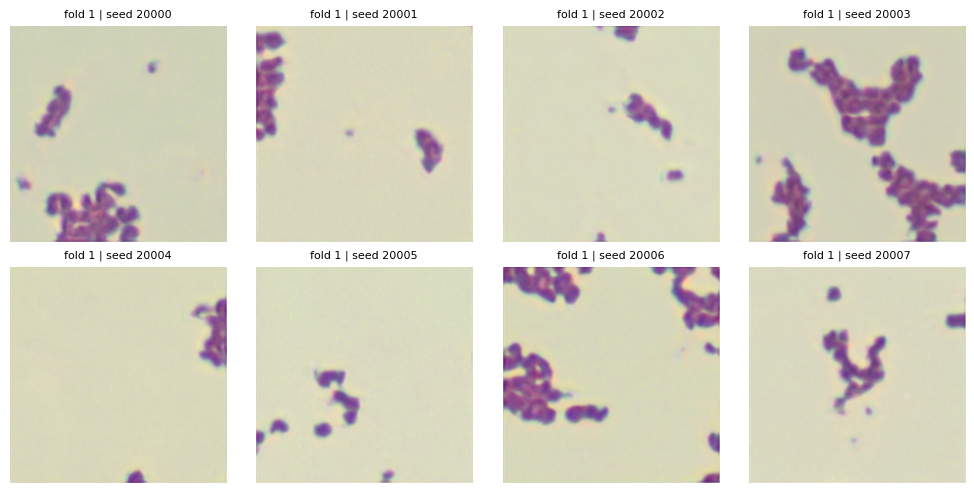

Saved sparse 224 manifest to: C:\Users\FYP2610\Downloads\FYP2\manifests\stylegan2_sparse_generated_manifest_224.csv


In [5]:
# We resize the new sparse generated images to 224x224 for CNN input.
generated_rows_224 = []

for row in generated_rows_256:
    fold_id = int(row["fold_id"])
    source_file = REPO_ROOT / row["file_path"]
    target_dir = GAN_IMAGES_224_DIR / f"fold_{fold_id}"
    target_dir.mkdir(parents=True, exist_ok=True)
    target_file = target_dir / source_file.name
    if target_file.exists() and not ALLOW_OVERWRITE_SPARSE_OUTPUTS:
        raise FileExistsError(
            f"Refusing to overwrite existing sparse 224 image: {target_file}. "
            "Set ALLOW_OVERWRITE_SPARSE_OUTPUTS=True only if you intentionally rerun this notebook."
        )

    with Image.open(source_file) as image:
        resized_image = image.resize((CNN_PATCH_SIZE, CNN_PATCH_SIZE), Image.Resampling.LANCZOS)
        resized_image.save(target_file)

    generated_rows_224.append({
        "dataset_name": row["dataset_name"],
        "gan_image_id": row["gan_image_id"].replace("_256", "_224"),
        "fold_id": row["fold_id"],
        "round_id": row["round_id"],
        "train_fold_id": row["train_fold_id"],
        "test_fold_ids": row["test_fold_ids"],
        "binary_label": row["binary_label"],
        "binary_group": row["binary_group"],
        "seed": row["seed"],
        "image_size": CNN_PATCH_SIZE,
        "file_path": as_repo_relative(REPO_ROOT, target_file),
        "source_file_256": row["file_path"],
        "snapshot_path": row["snapshot_path"],
        "source_type": SOURCE_TYPE,
    })

write_csv_rows(MANIFEST_224_PATH, generated_rows_224, list(generated_rows_224[0].keys()))

summary = {
    "dataset_name": DATASET_NAME,
    "source_notebook_tag": SOURCE_NOTEBOOK_TAG,
    "notebook_tag": NOTEBOOK_TAG,
    "no_gan_retraining": True,
    "snapshot_selection_kimg": SPARSE_SNAPSHOT_KIMG,
    "kid_metric_name": KID_METRIC_NAME,
    "generated_manifest_256": as_repo_relative(REPO_ROOT, MANIFEST_256_PATH),
    "generated_manifest_224": as_repo_relative(REPO_ROOT, MANIFEST_224_PATH),
    "source_type": SOURCE_TYPE,
}
write_json(NOTEBOOK_RESULTS_DIR / "summary.json", summary)

fold_result_rows = []
for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    fold_rows = [row for row in generated_rows_224 if int(row["fold_id"]) == fold_id]
    fold_result_rows.append({
        "fold_id": fold_id,
        "needed_gan_count_224": int(fold_plan["needed_gan_count_224"]),
        "generated_count_224": len(fold_rows),
        "selected_snapshot_kimg": int(kid_lookup[fold_id]["snapshot_kimg"]),
        "selected_kid50k_full": float(kid_lookup[fold_id]["kid50k_full"]),
    })
write_csv_rows(NOTEBOOK_RESULTS_DIR / "gan_summary_by_fold.csv", fold_result_rows, list(fold_result_rows[0].keys()))

display(pd.DataFrame(fold_result_rows))
display(pd.DataFrame(generated_rows_224).head(10))

# This small preview is only for visual audit of the new sparse images.
preview_rows = generated_rows_224[:8]
if preview_rows:
    fig, axes = plt.subplots(2, 4, figsize=(10, 5))
    axes = axes.flatten()
    for axis, preview_row in zip(axes, preview_rows):
        image_path = REPO_ROOT / preview_row["file_path"]
        with Image.open(image_path) as image:
            axis.imshow(image)
        axis.set_title(f"fold {preview_row['fold_id']} | seed {preview_row['seed']}", fontsize=8)
        axis.axis("off")
    for axis in axes[len(preview_rows):]:
        axis.axis("off")
    fig.tight_layout()
    fig.savefig(NOTEBOOK_RESULTS_DIR / "generated_preview_224.png", dpi=200)
    plt.show()

print(f"Saved sparse 224 manifest to: {MANIFEST_224_PATH}")